<a href="https://colab.research.google.com/github/LucasFortolan/Analise-Estatistica-de-Emprestimo-com-Regressao-Linear/blob/main/Aprendizado_Maquina_Titanic_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
# Talvez seja necessário executar esta célula novamente depois de fazer login.
kagglehub.login()
path = kagglehub.competition_download('titanic')
#KGAT_3efe27bdeb564d90d91f5f967c987a70

**Import Bibliotecas**

In [ ]:
import pandas as pd
from pathlib import Path

train = pd.read_csv(Path(path) / "train.csv")

**Informações do Dataframe**

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Cabeçalho**

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Análise Exploratória**
**Conhecendo o Dataframe e a influência dos dados**


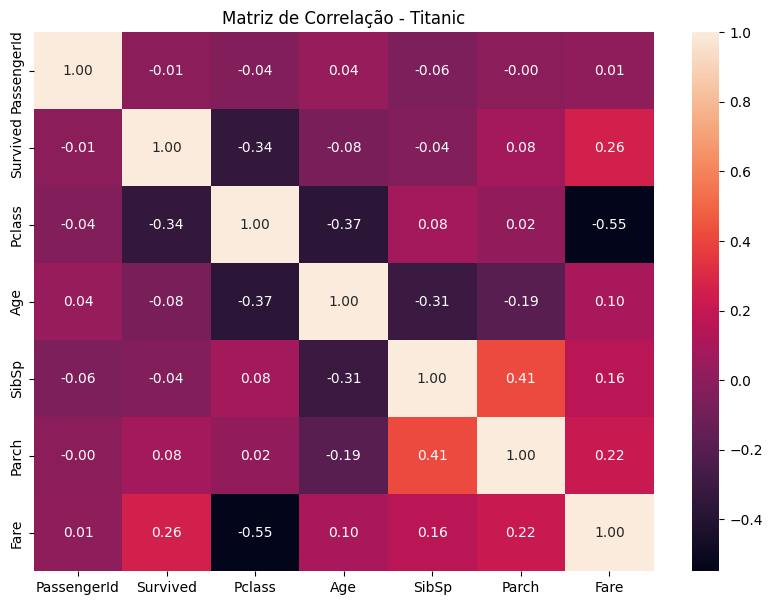

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlacao = train.corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de Correlação - Titanic")
plt.show()

**Sobreviventes**

In [ ]:
sum_survived = (train["Survived"] == 1).sum()
print("Total de Sobreviventes: ", sum_survived)
sum_died = (train["Survived"] == 0).sum()
print("Total de Mortos: ", sum_died)
total_passageiros = sum_survived + sum_died
print("Total de Passageiros: ", total_passageiros)
porc_survived = (sum_survived / total_passageiros) * 100
print(f"Porcentagem de Sobreviventes: {porc_survived:.2f}%", )

Total de Sobreviventes:  342
Total de Mortos:  549
Total de Passageiros:  891
Porcentagem de Sobreviventes: 38.38%


**O sexo influência na sobrevivência?**

In [ ]:
qtd_male = (train["Sex"] == "male").sum()
qtd_female = (train["Sex"] == "female").sum()
print(f"Qtd Total de Homens abordo: {qtd_male}")
print(f"Qtd Total de Mulheres abordo: {qtd_female}")

male_survived = ((train["Sex"] == "male") & (train["Survived"] == 1)).sum()
female_survived = ((train["Sex"] == "female") & (train["Survived"] == 1)).sum()
print(f"Qtd de Homens Sobreviventes: {male_survived}")
print(f"Qtd de Mulheres Sobreviventes: {female_survived}")

porc_male_survived = (male_survived / qtd_male) * 100
porc_female_survived = (female_survived / qtd_female) * 100
print(f"Porcentagem de Homens Sobreviventes: {porc_male_survived:.2f}%")
print(f"Porcentagem de Mulheres Sobreviventes: {porc_female_survived:.2f}%")

Qtd Total de Homens abordo: 577
Qtd Total de Mulheres abordo: 314
Qtd de Homens Sobreviventes: 109
Qtd de Mulheres Sobreviventes: 233
Porcentagem de Homens Sobreviventes: 18.89%
Porcentagem de Mulheres Sobreviventes: 74.20%


**A Classe influênciou na sobrevivência?**

QTD de 1º Classe: 216
QTD de 2º Classe: 184
QTD de 3º Classe: 491
Sobreviventes na 1º Classe: 136
Sobreviventes na 2º Classe: 87
Sobreviventes na 3º Classe: 119
Porcentagem de Sobreviventes 1º Classe: 62.96%
Porcentagem de Sobreviventes 2º Classe: 47.28%
Porcentagem de Sobreviventes 3º Classe: 24.24%


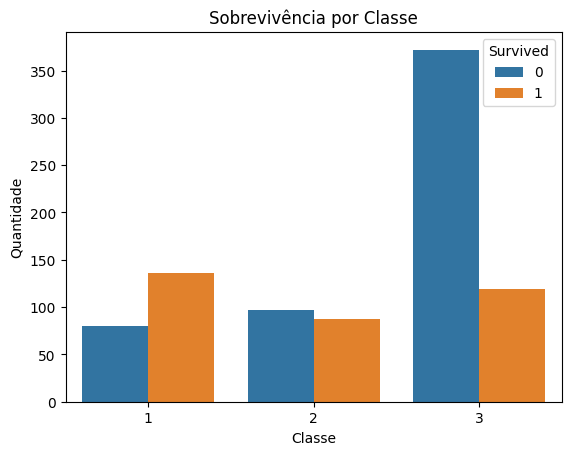

In [ ]:
first = (train['Pclass'] == 1).sum()
second = (train['Pclass'] == 2).sum()
third = (train['Pclass'] == 3).sum()

print(f"QTD de 1º Classe: {first}")
print(f"QTD de 2º Classe: {second}")
print(f"QTD de 3º Classe: {third}")

survived_first = ((train['Pclass'] == 1) & (train['Survived'] == 1)).sum()
survived_second = ((train['Pclass'] == 2) & (train['Survived'] == 1)).sum()
survived_third = ((train['Pclass'] == 3) & (train['Survived'] == 1)).sum()

print(f"Sobreviventes na 1º Classe: {survived_first}")
print(f"Sobreviventes na 2º Classe: {survived_second}")
print(f"Sobreviventes na 3º Classe: {survived_third}")

porc_first_survived = (survived_first / first)*100
porc_second_survived = (survived_second / second)*100
porc_third_survived = (survived_third / third)*100

print(f"Porcentagem de Sobreviventes 1º Classe: {porc_first_survived:.2f}%")
print(f"Porcentagem de Sobreviventes 2º Classe: {porc_second_survived:.2f}%")
print(f"Porcentagem de Sobreviventes 3º Classe: {porc_third_survived:.2f}%")

sns.countplot(data=train, x="Pclass", hue="Survived")

plt.title("Sobrevivência por Classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

**A Idade Influência na Sobrevivência?**


Bebês: 15/24 = 62.50%
Crianças: 24/44 = 54.55%
Adolescentes: 22/45 = 48.89%
Adultos: 222/575 = 38.61%
Idosos: 7/26 = 26.92%


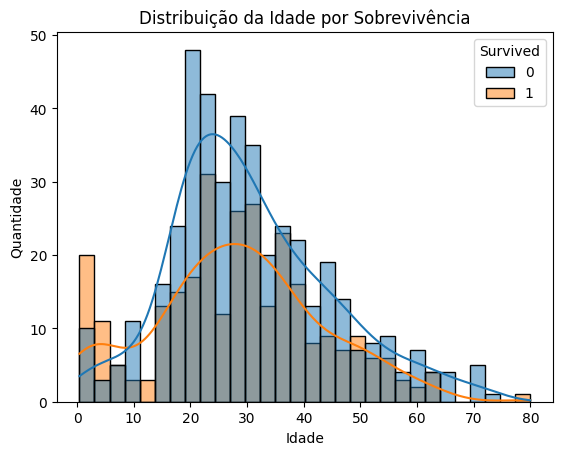

In [ ]:
total_baby = (train["Age"] < 3).sum()
total_kids = ((train["Age"] >= 3) & (train["Age"] < 12)).sum()
total_adolescentes = ((train["Age"] >= 12) & (train["Age"] < 18)).sum()
total_adulto = ((train["Age"] >= 18) & (train["Age"] < 60)).sum()
total_idoso = (train["Age"] >= 60).sum()

baby = ((train["Age"] < 3) & (train["Survived"] == 1)).sum()
kids = ((train["Age"] >= 3) & (train["Age"] < 12) & (train["Survived"] == 1)).sum()
adolescentes = ((train["Age"] >= 12) & (train["Age"] < 18) & (train["Survived"] == 1)).sum()
adulto = ((train["Age"] >= 18) & (train["Age"] < 60) & (train["Survived"] == 1)).sum()
idoso = ((train["Age"] >= 60) & (train["Survived"] == 1)).sum()

porc_baby = (baby / total_baby) * 100
porc_kids = (kids / total_kids) * 100
porc_adolescentes = (adolescentes / total_adolescentes) * 100
porc_adulto = (adulto / total_adulto) * 100
porc_idoso = (idoso / total_idoso) * 100

print(f"Bebês: {baby}/{total_baby} = {porc_baby:.2f}%")
print(f"Crianças: {kids}/{total_kids} = {porc_kids:.2f}%")
print(f"Adolescentes: {adolescentes}/{total_adolescentes} = {porc_adolescentes:.2f}%")
print(f"Adultos: {adulto}/{total_adulto} = {porc_adulto:.2f}%")
print(f"Idosos: {idoso}/{total_idoso} = {porc_idoso:.2f}%")

sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Distribuição da Idade por Sobrevivência")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.show()

**O sexo e classe no TITANIC influenciaram na sobrevivência?**

In [ ]:
pd.crosstab([train["Sex"], train["Pclass"]],train["Survived"], normalize="index")*100

Survived               0          1
Sex    Pclass                      
female 1        3.191489  96.808511
       2        7.894737  92.105263
       3       50.000000  50.000000
male   1       63.114754  36.885246
       2       84.259259  15.740741
       3       86.455331  13.544669

**Passageiros solos tiveram maior taxa de sobrevivência que aqueles acompanhados?**

Sozinhos: 537
Acompanhados: 354
Sobrevivência sozinho: 30.35%
Sobrevivência acompanhado: 50.56%


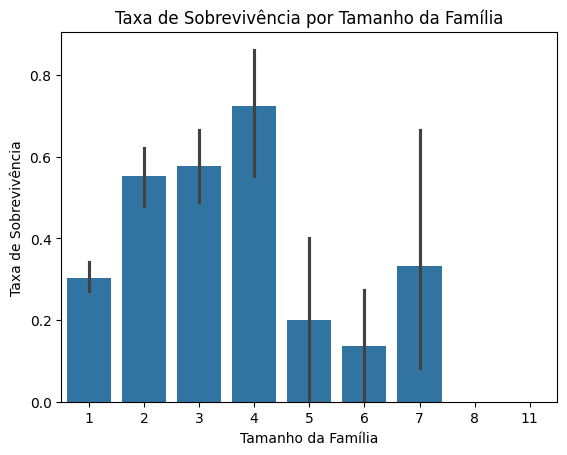

In [ ]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

sozinho = (train["FamilySize"] == 1).sum()
acompanhado = (train["FamilySize"] > 1).sum()

print(f"Sozinhos: {sozinho}")
print(f"Acompanhados: {acompanhado}")

sobreviveu_sozinho = ((train["FamilySize"] == 1) & (train["Survived"] == 1)).sum()

sobreviveu_acompanhado = ((train["FamilySize"] > 1) & (train["Survived"] == 1)).sum()

porc_sozinho = (sobreviveu_sozinho / sozinho) * 100
porc_acompanhado = (sobreviveu_acompanhado / acompanhado) * 100

print(f"Sobrevivência sozinho: {porc_sozinho:.2f}%")
print(f"Sobrevivência acompanhado: {porc_acompanhado:.2f}%")

pd.crosstab(train["FamilySize"], train["Survived"], normalize="index") * 100

sns.barplot(
    data=train,
    x="FamilySize",
    y="Survived"
)

plt.title("Taxa de Sobrevivência por Tamanho da Família")
plt.xlabel("Tamanho da Família")
plt.ylabel("Taxa de Sobrevivência")
plt.show()

# **Treino do Modelo de Previsão**

**Bibliotecas**

In [ ]:
from sklearn.model_selection import train_test_split
# Pré Processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
# Pós Processamento

In [ ]:
y = train["Survived"] # desejo prever

X = train[[ # informações usada para prever
  "Pclass",
  "Sex",
  "Age",
  "SibSp",
  "Parch",
  "Embarked"
]]


X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

**Pré-Processamento de Dados**

In [ ]:
numeric_collumn = [
  "Pclass",
  "Age",
  "SibSp",
  "Parch",
]

categorical_collumn = [
  "Sex",
  "Embarked"
]

numeric_transformer = Pipeline(steps=[
  ("imputer", SimpleImputer(strategy="median"))
])


categorical_transformer = Pipeline(steps=[
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(
  transformers=[
      ("num", numeric_transformer, numeric_collumn),
      ("cat", categorical_transformer, categorical_collumn)
  ]
)

**Pós Processamento**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
  ("preprocessor", preprocessor),
  ("classifier", LogisticRegression(max_iter=1000))
])

# Treinamento
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)

# Avaliação
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.2%}")

Acurácia: 81.01%


**Modelo 2**

In [ ]:
y = train["Survived"] # desejo prever

X = train[[ # informações usada para prever
  "Pclass",
  "Sex",
  "Age",
  "SibSp",
  "FamilySize",
  "Embarked"
]]


X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

In [ ]:
numeric_collumn = [
  "Pclass",
  "Age",
  "FamilySize"
]

categorical_collumn = [
  "Sex"
]

numeric_transformer = Pipeline(steps=[
  ("imputer", SimpleImputer(strategy="median"))
])


categorical_transformer = Pipeline(steps=[
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(
  transformers=[
      ("num", numeric_transformer, numeric_collumn),
      ("cat", categorical_transformer, categorical_collumn)
  ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
  ("preprocessor", preprocessor),
  ("classifier", LogisticRegression(max_iter=1000))
])

# Treinamento
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)

# Avaliação
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.2%}")

Acurácia: 80.45%


# **Realizando o Teste do Modelo**

In [ ]:
test = pd.read_csv(Path(path) / "test.csv")

test.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [ ]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

**Utilizando o melhor modelo: Modelo 1**

In [ ]:
y = train["Survived"]

X = train[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Embarked"
]]

**Pré Processamento**

In [ ]:
numeric_collumn = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch"
]

categorical_collumn = [
    "Sex",
    "Embarked"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_collumn),
        ("cat", categorical_transformer, categorical_collumn)
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [ ]:
model_final.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
X_submission = test[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Embarked"
]]

In [ ]:
predictions = model_final.predict(X_submission)

print(predictions)
print("Quantidade de previsões:", len(predictions))

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 1
 1 0 0 0 1 0 1 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0
 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]
Quantidade de previsões: 418


In [ ]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": predictions
})

In [ ]:
print(submission.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [ ]:
submission.to_csv("submission.csv", index=False)